
**Importations**



In [ ]:
# Bibliothèques nécessaires

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

**Préparation des données**

In [ ]:
# Chargement du dataset MNIST
# 60 000 images pour l'entraînement
# 10 000 images pour le test
# Chaque image représente un chiffre de 0 à 9

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalisation des pixels : [0, 255] -> [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Ajout du canal grayscale :
# (28, 28) -> (28, 28, 1)
x_train = x_train[..., None]
x_test = x_test[..., None]

print("Train :", x_train.shape)
print("Test  :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (60000, 28, 28, 1)
Test  : (10000, 28, 28, 1)


**Création du modèle**

In [ ]:
# CNN volontairement simple pour servir de modèle de départ
#un seul bloc convolutionnel :  Conv2D→ReLU→MaxPooling

model = Sequential([

    Input(shape=(28, 28, 1)),    # Image d'entrée : 28×28×1


    # 1 filtre de taille 7×7
    # 28×28×1 -> 22×22×1
    Conv2D(
        filters=1,
        kernel_size=(7, 7),
        activation='relu'
    ),

    # Réduction importante de la taille spatiale
    # 22×22×1 -> 3×3×1
    MaxPooling2D(
        pool_size=(7, 7)
    ),

    # 3×3×1 -> 9 valeurs
    Flatten(),

    # 10 classes : chiffres de 0 à 9
    Dense(
        10,
        activation='softmax'
    )
])

# Configuration de l'apprentissage
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Affichage de l'architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 1)      │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150 (600.00 B)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

**Expérimentation**

In [ ]:
# Entraînement du modèle
# 20 % du jeu d'entraînement est utilisé pour la validation

history = model.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4318 - loss: 1.6215 - val_accuracy: 0.5894 - val_loss: 1.2247
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6190 - loss: 1.1460 - val_accuracy: 0.6470 - val_loss: 1.0529
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6536 - loss: 1.0453 - val_accuracy: 0.6739 - val_loss: 0.9858


**Résultats et courbes**

Test loss     : 0.9512
Test accuracy : 0.6882


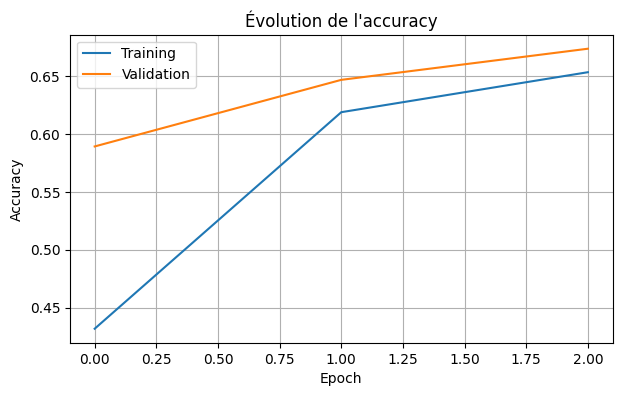

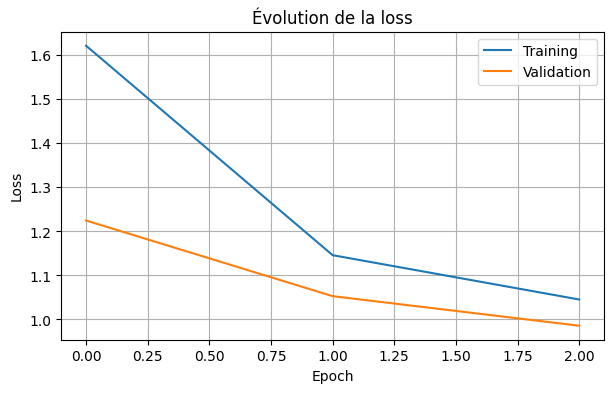

In [ ]:
# Évaluation finale sur le jeu de test

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss     :", round(test_loss, 4))
print("Test accuracy :", round(test_accuracy, 4))


# ------------------------------------------------------------
# Courbe Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Évolution de l'accuracy")
plt.legend()
plt.grid()

plt.show()


# ------------------------------------------------------------
# Courbe Loss
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Évolution de la loss")
plt.legend()
plt.grid()

plt.show()

**Tester le modèle sur une image personnelle**

Saving test.png to test (3).png


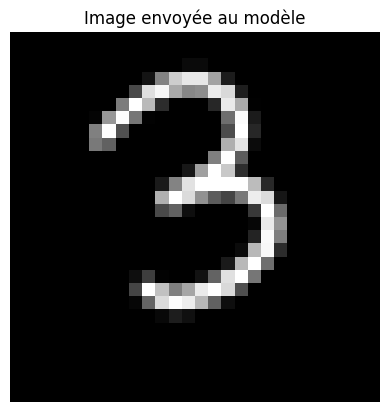

Chiffre prédit : 2
Probabilité     : 0.8518


In [ ]:
# ============================================================
# 6. Tester le modèle sur une image personnelle
# ============================================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Importer l'image
uploaded = files.upload()

# Récupérer le nom du fichier importé
filename = next(iter(uploaded))

# Ouvrir l'image et la convertir en niveaux de gris
img = Image.open(filename).convert('L')

# Redimensionnement au format MNIST
img = img.resize((28, 28))

# Conversion en tableau NumPy
x = np.array(img)

# MNIST contient généralement un chiffre clair sur fond noir.
# Si l'image est plutôt noire sur fond blanc, on inverse les couleurs.
if x.mean() > 127:
    x = 255 - x

# Normalisation : [0,255] -> [0,1]
x = x / 255.0

# Le modèle attend une entrée de forme :
# (nombre_images, hauteur, largeur, canaux)
# donc : (1, 28, 28, 1)
x = x.reshape(1, 28, 28, 1)

# Affichage de l'image réellement envoyée au modèle
plt.imshow(x[0, :, :, 0], cmap='gray')
plt.title("Image envoyée au modèle")
plt.axis('off')
plt.show()

# Prédiction
prediction = model.predict(x, verbose=0)

# Classe ayant la probabilité la plus élevée
chiffre_predit = np.argmax(prediction[0])

# Probabilité associée
probabilite = prediction[0][chiffre_predit]

print("Chiffre prédit :", chiffre_predit)
print("Probabilité     :", round(float(probabilite), 4))